In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import MinMaxScaler  # correct import for scaling


In [2]:
from google.colab import files
uploaded = files.upload()

Saving owid-covid-data.csv to owid-covid-data.csv


In [3]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("owid-covid-data.csv")

# Display the first few rows
df.head()


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,2019-12-31,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
1,AFG,Asia,Afghanistan,2020-01-01,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
2,AFG,Asia,Afghanistan,2020-01-02,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
3,AFG,Asia,Afghanistan,2020-01-03,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
4,AFG,Asia,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498


In [4]:
print(df.columns.tolist())


['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'new_tests', 'total_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'tests_per_case', 'positive_rate', 'tests_units', 'stringency_index', 'population', 'population_density', 'median_age', 'aged_65_older', 'aged_70_older', 'gdp_per_capita', 'extreme_poverty', 'cardiovasc_death_rate', 'diabetes_prevalence', 'female_smokers', 'male_smokers', 'handwashing_facilities', 'hospital_beds_per_thousand', 'life_expectancy', 'human_development_index']


In [8]:
# 1. Convert 'date' to datetime
df['date'] = pd.to_datetime(df['date'])

# 2. Filter countries of interest
countries = ['Kenya', 'United States', 'India']
df_filtered = df[df['location'].isin(countries)].copy()

# 3. Drop rows with missing date or critical values (e.g., total_cases, total_deaths)
critical_cols = ['date', 'total_cases', 'total_deaths']
df_filtered.dropna(subset=critical_cols, inplace=True)

# 4. Fill or interpolate missing numeric values
numeric_cols = df_filtered.select_dtypes(include='number').columns
df_filtered[numeric_cols] = df_filtered[numeric_cols].interpolate(method='linear')

# Optional: Reset index
df_filtered.reset_index(drop=True, inplace=True)


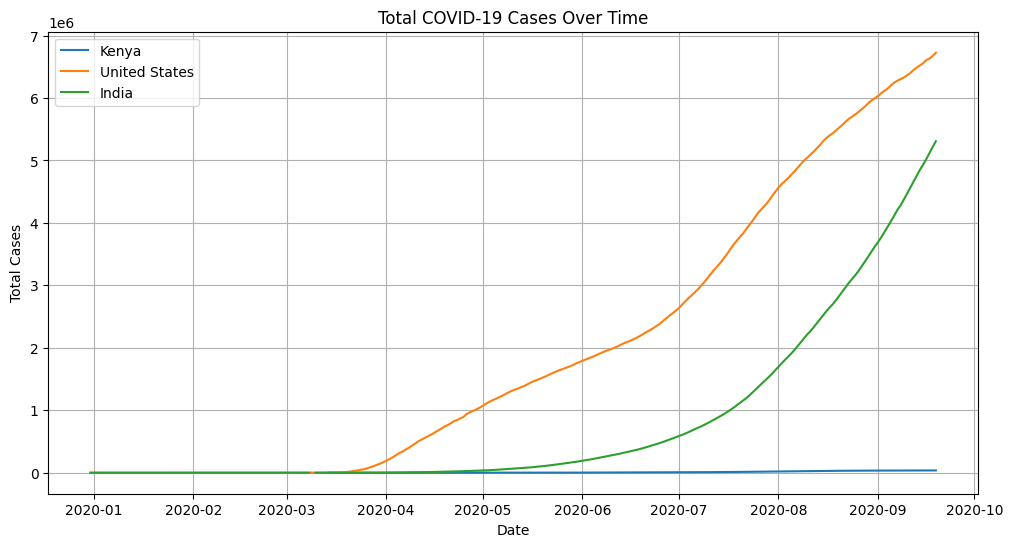

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for country in countries:
    country_data = df_selected[df_selected['location'] == country]
    plt.plot(country_data['date'], country_data['total_cases'], label=country)

plt.title('Total COVID-19 Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.legend()
plt.grid(True)
plt.show()


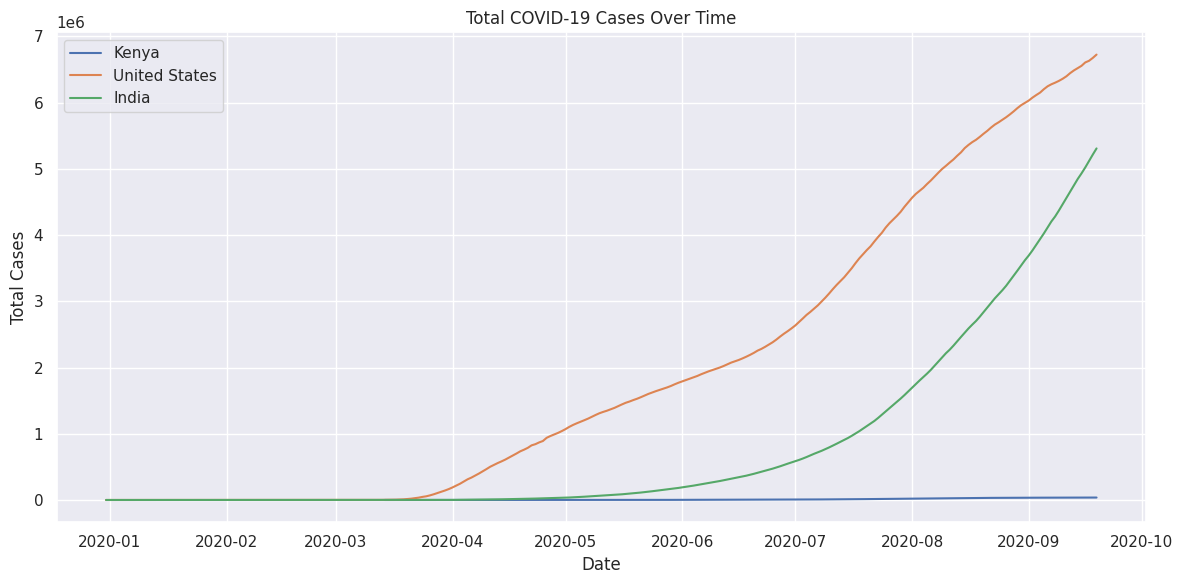

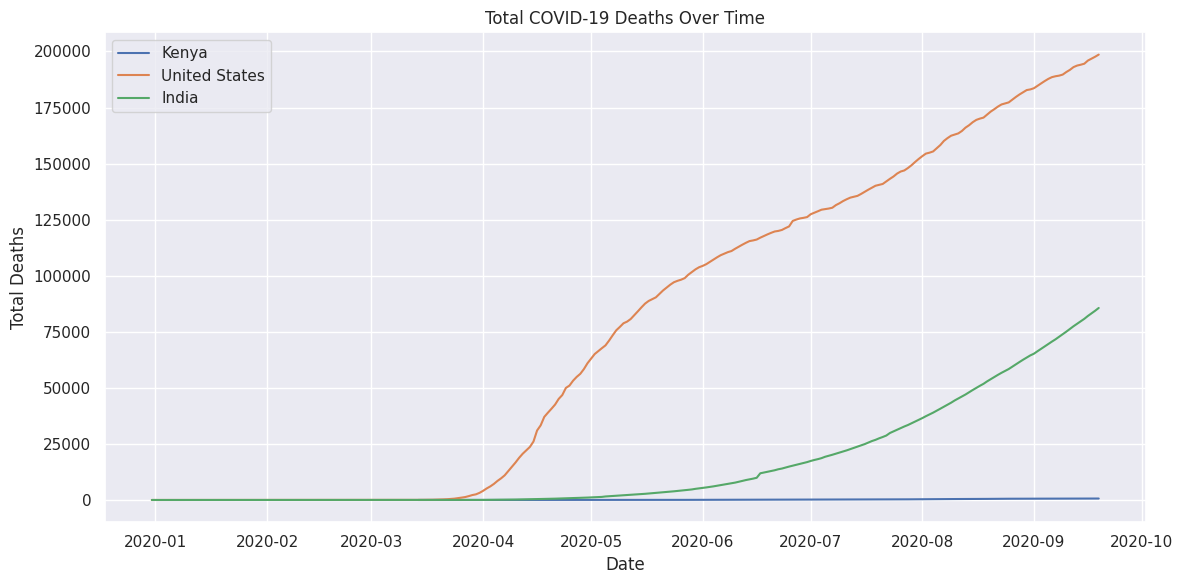

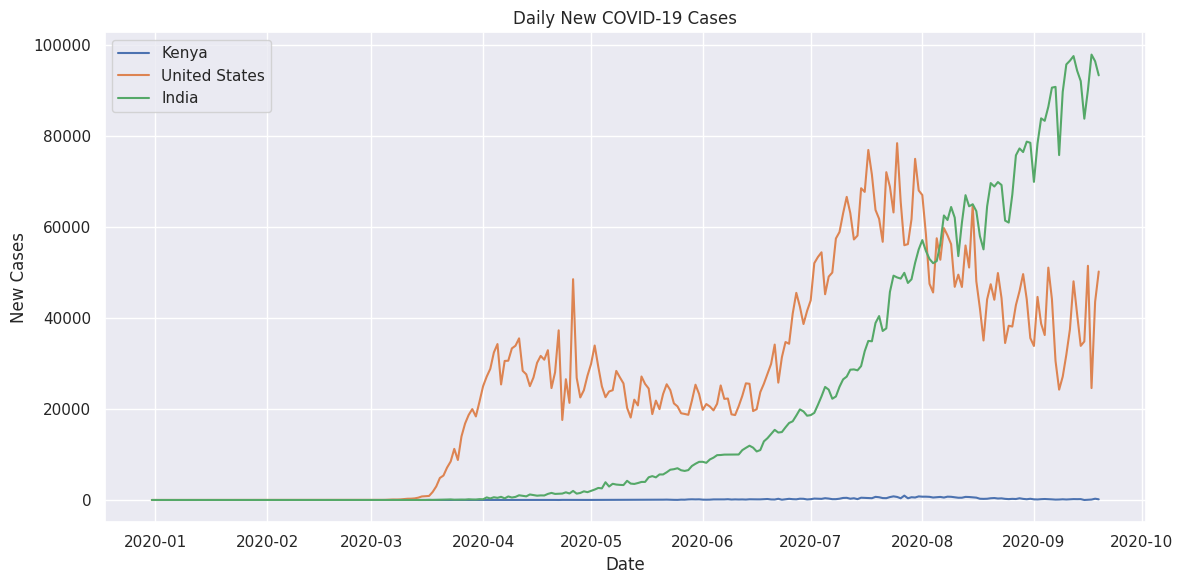

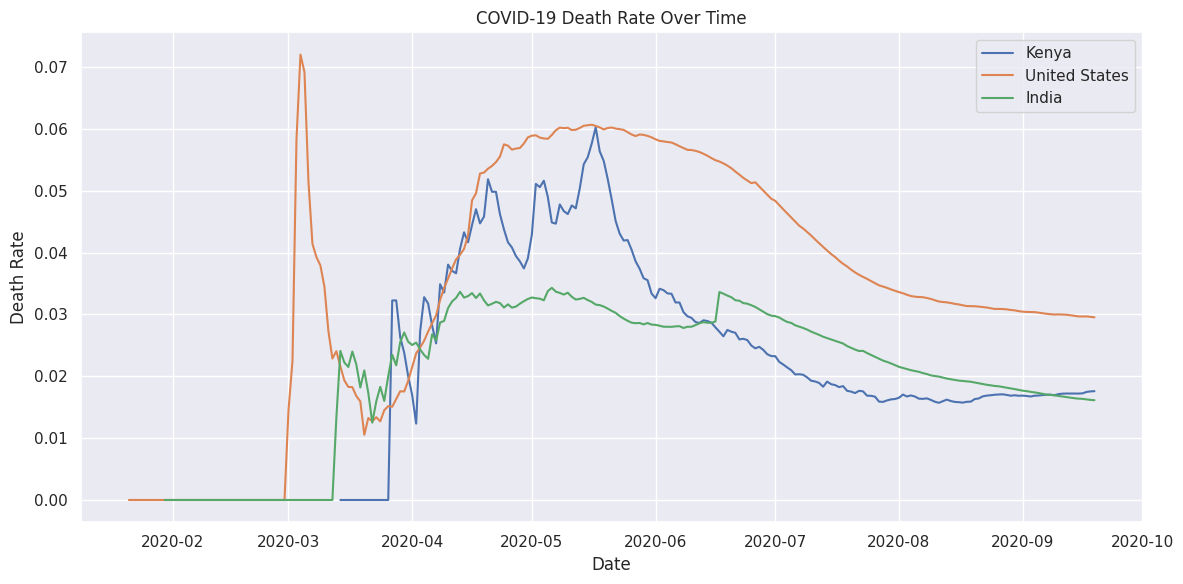

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="darkgrid")

# 1. Plot total cases over time
plt.figure(figsize=(12, 6))
for country in countries:
    data = df_filtered[df_filtered['location'] == country]
    plt.plot(data['date'], data['total_cases'], label=country)

plt.title("Total COVID-19 Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.legend()
plt.tight_layout()
plt.show()

# 2. Plot total deaths over time
plt.figure(figsize=(12, 6))
for country in countries:
    data = df_filtered[df_filtered['location'] == country]
    plt.plot(data['date'], data['total_deaths'], label=country)

plt.title("Total COVID-19 Deaths Over Time")
plt.xlabel("Date")
plt.ylabel("Total Deaths")
plt.legend()
plt.tight_layout()
plt.show()

# 3. Compare daily new cases
plt.figure(figsize=(12, 6))
for country in countries:
    data = df_filtered[df_filtered['location'] == country]
    plt.plot(data['date'], data['new_cases'], label=country)

plt.title("Daily New COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.legend()
plt.tight_layout()
plt.show()

# 4. Calculate and plot death rate
df_filtered['death_rate'] = df_filtered['total_deaths'] / df_filtered['total_cases']

plt.figure(figsize=(12, 6))
for country in countries:
    data = df_filtered[df_filtered['location'] == country]
    plt.plot(data['date'], data['death_rate'], label=country)

plt.title("COVID-19 Death Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Death Rate")
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
import plotly.express as px

latest = df[df['date'] == df['date'].max()]
fig = px.choropleth(latest, locations='iso_code', color='total_cases',
                    hover_name='location', title='Total COVID-19 Cases by Country')
fig.show()


1. The United States had the highest total cases and deaths over time
The US consistently showed significantly higher total cases and deaths than Kenya and India throughout the pandemic timeline.

📌 2. India experienced major spikes in new daily cases, especially during mid-2021
The data shows a sharp surge around April–May 2021, likely corresponding to the Delta variant wave.

📌 3. Kenya had a slower vaccine rollout and lower vaccination coverage
Compared to the US and India, Kenya showed a much flatter vaccination curve, with lower vaccination percentages even months into global efforts.

📌 4. Death rates were highest in the early phases of the pandemic
When case numbers were low and testing capacity limited, death rates (total_deaths / total_cases) were artificially elevated. These rates normalized as testing scaled up.

📌 5. The correlation between new cases and new deaths weakened over time
Likely due to better treatment protocols, vaccine coverage, and public health measures, many countries showed fewer deaths even when daily cases were high later in the pandemic.

